# Verification — innate immune response to IFN-beta and poly(I:C) (Korwek et al., 2023)

Korwek Z, Czerkies M, Jaruszewicz-Blonska J, Prus W, Kosiuk I, Kochanczyk M, Lipniacki T
(2023). *Nonself RNA rewires IFN-beta signaling: A mathematical model of the innate immune
response.* **Science Signaling** 16:eabq1173. doi:[10.1126/scisignal.abq1173](https://doi.org/10.1126/scisignal.abq1173)

This notebook verifies the curated collection at three levels.

**1. Source fidelity.** The authors publish their own BioNetGen file as data file S2. The
curated primary file is a house-style rewrite of it — reordered, regrouped, annotated, with
units comments and a `#@figure:`-tagged actions block — so the first and strictest check is
that the rewrite did not change the model: BioNetGen output from the curated file is compared
against BioNetGen output from the authors' file, observable by observable and time point by
time point.

**2. Model-specification verification.** `independent_korwek2023.py` implements the 53-species
ODE system directly from the *reaction rules*, in NumPy/SciPy, without reading BioNetGen's
generated `.net` file. It therefore independently checks BioNetGen's network generation, its
treatment of the saturating functional rate laws (the competitive NF-kB/IkBa promoter terms,
the RNase L transcript-degradation factor, the phospho-eIF2alpha translation-arrest factor,
the STAT saturation terms), and the observable pattern definitions — including the ones that
are easy to get wrong, such as `IFNb_ext`, which matches the receptor-bound ligand as well as
the free extracellular pool, and `STAT1_p`, which counts the STAT1/2 heterodimer.

**3. Reported-data verification.** The paper reports no tabular data, so the published model
trajectories *and* the quantified Western blots are recovered from figs. S4 and S12 by
`digitize_korwek2023.py` and compared quantitatively against the curated simulations.

In [1]:
import json, subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import independent_korwek2023 as indep

HERE = Path.cwd()
REF = HERE / "reference"
BNGPATH = Path.home() / "Simulations" / "BioNetGen-2.9.3"
STEM = "innate_immune_response_korwek2023"

# Wall-clock times, in seconds, at which each protocol applies its stimulus. Phase 1 of every
# actions block is a 30-day equilibration that is not written to the .gdat, so the recorded
# clock starts at 0 and the stimulus lands at T_STIM.
T_STIM = 13600.0


def read_gdat(path):
    with open(path) as fh:
        cols = fh.readline().lstrip("#").split()
    return pd.DataFrame(np.loadtxt(path), columns=cols)


FILES = {
    "primary":   f"{STEM}.bngl",          # IFN-beta 24 h -> poly(I:C) 10 h
    "ifnb":      f"{STEM}_ifnb.bngl",     # IFN-beta 34 h
    "polyic":    f"{STEM}_polyic.bngl",   # poly(I:C) 10 h
    "tnfa":      f"{STEM}_tnfa.bngl",     # TNF-alpha 6 h, WT
    "tnfa_ko":   f"{STEM}_tnfa_a20ko.bngl",  # TNF-alpha 6 h, A20 KO
}
GDAT = {
    "primary": REF / f"{STEM}_ode.gdat",
    "ifnb":    REF / f"{STEM}_ifnb_ode.gdat",
    "polyic":  REF / f"{STEM}_polyic_ode.gdat",
    "tnfa":    REF / f"{STEM}_tnfa_ode.gdat",
    "tnfa_ko": REF / f"{STEM}_tnfa_a20ko_ode.gdat",
}
sim = {k: read_gdat(v) for k, v in GDAT.items()}
for k, df in sim.items():
    print(f"{k:9s} {df.shape[0]:5d} rows x {df.shape[1]-1:2d} observables, "
          f"t = {df['time'].iloc[0]:.0f} .. {df['time'].iloc[-1]:.0f} s")

primary    4321 rows x 42 observables, t = 0 .. 136000 s
ifnb       3481 rows x 42 observables, t = 0 .. 136000 s
polyic     2881 rows x 42 observables, t = 0 .. 49600 s
tnfa       3601 rows x 42 observables, t = 0 .. 35200 s
tnfa_ko    3601 rows x 42 observables, t = 0 .. 35200 s


## Optional — regenerate the reference outputs

The committed `reference/*.gdat` files are what the rest of the notebook reads. Set
`REGENERATE = True` to re-run all five BNGL files through BioNetGen first and confirm the
committed outputs are current.

In [2]:
REGENERATE = False

if REGENERATE:
    import shutil, tempfile
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        for name in FILES.values():
            shutil.copy(HERE / name, tmp / name)
        for key, name in FILES.items():
            subprocess.run(["perl", str(BNGPATH / "BNG2.pl"), name],
                           cwd=tmp, check=True, capture_output=True)
            fresh = read_gdat(tmp / (Path(name).stem + "_ode.gdat"))
            old = sim[key]
            assert list(fresh.columns) == list(old.columns)
            d = np.abs(fresh.to_numpy() - old.to_numpy()).max()
            print(f"{key:9s} regenerated, max |difference| vs committed reference = {d:.3e}")

## 1. Source fidelity — the curated file *is* the authors' model

The authors' `innate_immunity.bngl` (data file S2) is a primary source and is not
redistributable, so it is not committed here. If a copy is available, point `AUTHOR_BNGL` at
it and this section runs; otherwise it reports that it was skipped.

The curated primary file rewrites the authors' file into house style — blocks reordered,
parameters regrouped with units comments, observables regrouped, rules re-commented, the
actions block re-expressed as `simulate({method=>"ode",suffix=>"ode",...})` — and adds one
parameter, `h_A20_gene`, which multiplies TNFAIP3 transcription and is 1 (inert) in the
primary file. Nothing else is intended to differ, so the comparison should be exact, not
merely close.

In [3]:
AUTHOR_BNGL = (HERE.parents[1] / "dev" / "papers" / "Korwek-2023"
               / "scisignal.abq1173_data_files_s1_and_s2" / "Korwek_et_al__Software"
               / "innate_immunity.bngl")

if AUTHOR_BNGL.exists():
    import shutil, tempfile
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        shutil.copy(AUTHOR_BNGL, tmp / "author.bngl")
        subprocess.run(["perl", str(BNGPATH / "BNG2.pl"), "author.bngl"],
                       cwd=tmp, check=True, capture_output=True)
        author = read_gdat(tmp / "author.gdat")
    ours = sim["primary"]
    shared = [c for c in author.columns if c in ours.columns]
    assert set(author.columns) == set(ours.columns), "observable sets differ"
    assert len(author) == len(ours), "time grids differ"
    worst = max(np.abs(author[c].to_numpy() - ours[c].to_numpy()).max() for c in shared)
    print(f"observables compared : {len(shared)}")
    print(f"time points compared : {len(ours)}")
    print(f"max |curated - authors' data file S2| = {worst:.3e}")
    assert worst == 0.0, "the house-style rewrite changed the model"
    print("\nPASS - bit-for-bit identical to the authors' published BioNetGen model.")
else:
    print(f"SKIPPED - authors' BNGL not found at {AUTHOR_BNGL}")

observables compared : 43
time points compared : 4321
max |curated - authors' data file S2| = 0.000e+00

PASS - bit-for-bit identical to the authors' published BioNetGen model.


## 2. Model-specification verification — independent SciPy integration

`independent_korwek2023.py` builds the right-hand side from the reaction rules by hand. Two
places where a rule-based model can silently disagree with a naive transcription, and which
this check therefore exercises:

* the poly(I:C) sensors are switched on by the pattern `PolyIC(loc~cyt)`, which matches free
  cytoplasmic poly(I:C) **and** poly(I:C) inside the binary RIG-I complex **and** inside the
  ternary RIG-I:MAVS complex, so the catalyst is the total cytoplasmic pool, not the free one;
* `b_Nfkb_Ikba_nuc = k_v * b_Nfkb_Ikba_cyt` carries the cytoplasm-to-nucleus volume ratio, so
  nuclear association is five times faster than cytoplasmic association at equal amounts.

Each protocol is integrated on exactly the BioNetGen output grid, phase by phase, with the
same stimulus applications. The one time point that is deliberately excluded is the instant of
stimulation itself: BioNetGen writes the last row of the preceding phase *before* applying
`setConcentration`, so at that single row the two records legitimately disagree by the size of
the applied dose.

In [4]:
PROTOCOLS = {
    "primary": [(0.0, 13600.0, {}), (13600.0, 100000.0, {"IFNb_ext": 1.0}),
                (100000.0, 136000.0, {"PolyIC_ext": 1.0})],
    "ifnb":    [(0.0, 13600.0, {}), (13600.0, 136000.0, {"IFNb_ext": 1.0})],
    "polyic":  [(0.0, 13600.0, {}), (13600.0, 49600.0, {"PolyIC_ext": 1.0})],
    "tnfa":    [(0.0, 13600.0, {}), (13600.0, 35200.0, {"TNFa": 1.0})],
    "tnfa_ko": [(0.0, 13600.0, {}), (13600.0, 35200.0, {"TNFa": 1.0})],
}
KO = {"tnfa_ko": {"h_A20_gene": 0.0}}

spec_rows = []
for key, phases in PROTOCOLS.items():
    bng = sim[key]
    t_ind, Y = indep.integrate(phases, bng["time"].to_numpy(),
                               overrides=KO.get(key, {}))
    obs = indep.observable_frame(Y)
    assert len(obs) == len(bng)
    # exclude the single pre-setConcentration row at each stimulation instant
    keep = np.ones(len(bng), bool)
    for a, _b, sets in phases[1:]:
        if sets:
            keep[np.argmin(np.abs(bng["time"].to_numpy() - a))] = False
    for c in obs.columns:
        ref = bng[c].to_numpy()[keep]
        alt = obs[c].to_numpy()[keep]
        spec_rows.append(dict(protocol=key, observable=c,
                              scale=np.abs(ref).max(),
                              max_abs_dev=np.abs(ref - alt).max()))
spec = pd.DataFrame(spec_rows)
spec["max_norm_dev"] = spec.max_abs_dev / spec.scale.clip(lower=1e-300)

# Every pool in this nondimensionalized model is at most O(1), so an observable whose whole
# trajectory stays below ZERO_SCALE is a module the protocol never engages: p-IRF3, active
# IKK and cytoplasmic IFN-beta under IFN-beta alone, the STAT1/2 heterodimer under TNF-alpha,
# and so on. Their peak values run from 1e-31 to 6e-8, i.e. from the far side of double
# precision up to the two solvers' own noise floor, so a *relative* comparison of them is
# meaningless. They are held to an absolute bound instead; everything else to a relative one.
ZERO_SCALE, SPEC_TOL, ZERO_TOL = 1e-6, 1e-3, 1e-6
active = spec[spec.scale >= ZERO_SCALE]
quiescent = spec[spec.scale < ZERO_SCALE]

print(f"{len(spec)} protocol x observable comparisons over "
      f"{sum(len(sim[k]) for k in PROTOCOLS)} time points")
print(f"  {len(active)} active (peak amount >= {ZERO_SCALE:g}), "
      f"{len(quiescent)} numerically quiescent\n")
print("worst 8 active comparisons:")
print(active.sort_values("max_norm_dev", ascending=False)
      .head(8)[["protocol", "observable", "scale", "max_norm_dev"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3e}"))
print(f"\nactive     : max normalized deviation {active.max_norm_dev.max():.3e} "
      f"(tolerance {SPEC_TOL:g})")
print(f"quiescent  : max absolute deviation   {quiescent.max_abs_dev.max():.3e} "
      f"(tolerance {ZERO_TOL:g}), largest peak amount {quiescent.scale.max():.3e}")
assert active.max_norm_dev.max() < SPEC_TOL
assert quiescent.max_abs_dev.max() < ZERO_TOL
print("\nPASS - BioNetGen agrees with the independent implementation.")

210 protocol x observable comparisons over 17885 time points
  183 active (peak amount >= 1e-06), 27 numerically quiescent

worst 8 active comparisons:
protocol     observable     scale  max_norm_dev
 tnfa_ko IkBa_nuc_total 3.893e-03     6.868e-05
 tnfa_ko  IkBa_nuc_free 3.860e-03     6.684e-05
    tnfa  IkBa_nuc_free 3.860e-03     5.082e-05
    tnfa IkBa_nuc_total 3.893e-03     4.609e-05
 primary  IkBa_nuc_free 3.860e-03     2.362e-05
  polyic  IkBa_nuc_free 3.860e-03     1.972e-05
    ifnb            A20 3.809e-03     1.882e-05
 primary IkBa_nuc_total 3.893e-03     1.865e-05

active     : max normalized deviation 6.868e-05 (tolerance 0.001)
quiescent  : max absolute deviation   6.369e-08 (tolerance 1e-06), largest peak amount 6.369e-08

PASS - BioNetGen agrees with the independent implementation.


The tolerance is $10^{-3}$ of each observable's full scale, which is loose relative to the
result. It is set by the two integrators' error control, not by the model: BioNetGen uses
CVODE with its default tolerances, the independent implementation uses LSODA at
`rtol = 1e-11`, and the residual deviation is dominated by the stiff 30-day equilibration
that precedes every protocol.

## 3. Reported-data verification

### 3.1 What is being compared, and the normalization

The blots in Korwek et al. (2023) are quantified as a *relative level*: each protein's lane
intensities are normalized to a loading control and then to an arbitrary per-blot reference,
which is why every panel straddles 1 on a log axis. The model trajectories the authors plot
alongside them carry the same per-panel factor. That factor is not published and is not
recoverable from the model, so the comparison here fits **one multiplicative constant per
published panel and observable** in log space and reports the residual scatter around it.
Shape, not absolute level, is what is being tested — which is the right test, because the
level is a property of the blot normalization and the shape is a property of the model.

Two classes of point are excluded, both flagged in the digitized CSVs:

* `on_axis_floor` — the marker sits at or below ~0.115, the bottom of the 0.1 .. 10 axis.
  Where the model's prediction is effectively zero (p-IRF3 in the unstimulated lanes of
  fig. S4A; A20 in the A20 KO panel of fig. S12B, which the figure draws as a flat placeholder
  at 1) the published figure still draws a marker at a small positive display value, so these
  are display artifacts, not predictions.
* `above_axis` — the marker is clipped by the top of the axis at 10.

A third exclusion is applied on the simulation side, for the same reason. Where the model
predicts an amount that is numerically zero — p-IRF3 and active IKK before any stimulus,
p-STAT1/2 in the untreated lane — the ratio of published to simulated is not a measurement of
anything. A lane is used only if the simulated value is at least $10^{-3}$ of the largest
simulated value in that panel.

In [5]:
s4 = pd.read_csv(REF / "korwek2023_figS4_digitized.csv")
s12 = pd.read_csv(REF / "korwek2023_figS12_digitized.csv")

# fig. S4 observable -> model observable
S4_MAP = {"p-STAT1": "STAT1_p", "STAT1": "STAT1_total", "p-STAT2": "STAT2_p",
          "STAT2": "STAT2_total", "PKR": "PKR_total", "p-eIF2a": "eIF2a_p",
          "RIG-I": "RIG_I_total", "p-IRF3": "IRF3_p", "IkBa": "IkBa_total",
          "A20": "A20", "RNase L": "RNaseL_total", "OAS3": "OAS3_total"}
S12_MAP = {"NF-kB nuclear": "NFkB_nuc_total", "p-IKK": "IKK_a",
           "IkBa": "IkBa_total", "A20": "A20"}


def at(protocol, observable, t_seconds):
    df = sim[protocol]
    return np.interp(t_seconds, df["time"].to_numpy(), df[observable].to_numpy())


def fit_scale(published, simulated):
    # single multiplicative constant in log space, plus the residual ratios
    s = float(np.exp(np.mean(np.log(published / simulated))))
    return s, published / (simulated * s)

### 3.2 fig. S4 — IFN-beta, IFN-beta + poly(I:C), and poly(I:C) alone

fig. S4A places the ten lanes of Fig. 2A/2B side by side. Lanes 1-6 are the IFN-beta-only
protocol at 0, 24, 26, 28, 30 and 34 h (the `_ifnb` file); lanes 7-10 add poly(I:C) after 24 h
of IFN-beta and are read 2, 4, 6 and 10 h later (the primary file). Both protocols share the
first 24 h exactly, so lanes 1 and 2 are common to them. fig. S4C is the poly(I:C)-only
protocol (the `_polyic` file) with a 24 h IFN-beta lane appended for reference.

In [6]:
# lane -> (protocol, model time in seconds)
S4A_LANES = [("ifnb", 13600.0), ("ifnb", 100000.0), ("ifnb", 107200.0), ("ifnb", 114400.0),
             ("ifnb", 121600.0), ("ifnb", 136000.0),
             ("primary", 107200.0), ("primary", 114400.0), ("primary", 121600.0),
             ("primary", 136000.0)]
S4B_LANES = S4A_LANES[:6] + [(None, None)] + S4A_LANES[6:]      # lane 7 is IFN-beta 48 h
S4C_LANES = [("polyic", 13600.0), ("polyic", 20800.0), ("polyic", 28000.0),
             ("polyic", 35200.0), ("polyic", 49600.0), ("ifnb", 100000.0)]
S4_LANES = {"S4A": S4A_LANES, "S4B": S4B_LANES, "S4C": S4C_LANES, "S4D": S4C_LANES}


def compare_panel(df, panel, observable, lanes, key_col="lane"):
    sub = df[(df.panel == panel) & (df.observable == observable)].sort_values(key_col)
    pub, mod, keep = [], [], []
    for (_, row), (proto, t) in zip(sub.iterrows(), lanes):
        v = row["model"]
        usable = (proto is not None and np.isfinite(v)
                  and row["model_on_axis_floor"] == 0 and row["model_above_axis"] == 0)
        pub.append(v)
        mod.append(np.nan if proto is None else at(proto, S4_MAP.get(observable) or
                                                   S12_MAP[observable], t))
        keep.append(bool(usable) and np.isfinite(mod[-1]) and mod[-1] > 0)
    pub, mod, keep = np.array(pub, float), np.array(mod, float), np.array(keep)
    finite = np.isfinite(mod)
    if finite.any():
        keep &= mod > 1e-3 * np.nanmax(mod[finite])
    s, res = fit_scale(pub[keep], mod[keep])
    return sub, pub, mod, keep, s, res


rows = []
for panel in ["S4A", "S4B", "S4C", "S4D"]:
    for observable in sorted(s4[s4.panel == panel].observable.unique(),
                             key=lambda o: list(S4_MAP).index(o)):
        _, _, _, keep, s, res = compare_panel(s4, panel, observable, S4_LANES[panel])
        rows.append(dict(panel=panel, observable=observable, n=int(keep.sum()),
                         scale=s, median_pct=100 * np.median(np.abs(res - 1)),
                         max_pct=100 * np.max(np.abs(res - 1))))
s4_stats = pd.DataFrame(rows)
print(s4_stats.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
ok = s4_stats.n >= 3
print(f"\nfig. S4: {s4_stats.n.sum()} usable published model points across "
      f"{int(ok.sum())} panel x observable series")
print(f"  median of the per-series median relative deviations : "
      f"{np.median(s4_stats.median_pct[ok]):.1f}%")
print(f"  worst per-series median                             : "
      f"{s4_stats.median_pct[ok].max():.1f}%  "
      f"({s4_stats.loc[s4_stats.median_pct[ok].idxmax(), 'panel']} "
      f"{s4_stats.loc[s4_stats.median_pct[ok].idxmax(), 'observable']})")

panel observable  n  scale  median_pct  max_pct
  S4A    p-STAT1  9    120        8.63     50.2
  S4A      STAT1 10   1.66        1.58     12.2
  S4A    p-STAT2  9    122        9.37     47.6
  S4A      STAT2 10   1.89        3.47     32.4
  S4A        PKR 10   1.33        1.35     6.25
  S4A    p-eIF2a 10   15.2         8.1     13.2
  S4A      RIG-I 10   1.93        3.77       35
  S4A     p-IRF3  3   92.6        8.35     12.3
  S4A       IkBa 10   2.64        17.4     68.4
  S4A        A20 10    249        2.37     18.5
  S4A    RNase L 10   1.32       0.692     1.76
  S4B       OAS3 10   1.35       0.849     3.68
  S4C    p-STAT1  5    181        12.2     27.8
  S4C      STAT1  6   4.52        1.32     5.78
  S4C    p-STAT2  5    245        10.6     29.4
  S4C      STAT2  6   8.28        6.05     14.2
  S4C        PKR  6   2.22        1.84     4.48
  S4C    p-eIF2a  6   11.9        2.88     4.75
  S4C      RIG-I  6   9.46        5.73     15.1
  S4C     p-IRF3  4    270        8.88  

### 3.3 fig. S12 — TNF-alpha calibration of the NF-kB module

TNF-alpha reaches only the NF-kB module: the poly(I:C), IRF3, IFN-beta and STAT modules stay
quiescent, which is why Korwek et al. use this protocol to calibrate the NF-kB rate constants
against Lipniacki et al. (2004) and Tay et al. (2010). fig. S12A follows nuclear NF-kB (RelA)
in the nuclear fraction; fig. S12B follows p-IKK, IkBa and A20 in wild-type cells on a fine
and a long time base, and in A20 KO cells.

The A20 KO panel is a genuine prediction rather than a fit target: `h_A20_gene = 0` removes
the slower of the two NF-kB negative feedbacks, and the published model curves show the
consequence — a p-IKK plateau that settles higher than wild type and does not decay.

In [7]:
S12_PANELS = [("S12A", "NF-kB nuclear", "tnfa"),
              ("S12B_WT_fine", "p-IKK", "tnfa"), ("S12B_WT_fine", "IkBa", "tnfa"),
              ("S12B_WT_fine", "A20", "tnfa"),
              ("S12B_WT_long", "p-IKK", "tnfa"), ("S12B_WT_long", "IkBa", "tnfa"),
              ("S12B_WT_long", "A20", "tnfa"),
              ("S12B_A20KO_long", "p-IKK", "tnfa_ko"),
              ("S12B_A20KO_long", "IkBa", "tnfa_ko"),
              ("S12B_A20KO_long", "A20", "tnfa_ko")]

rows, cache = [], {}
for panel, observable, proto in S12_PANELS:
    sub = s12[(s12.panel == panel) & (s12.observable == observable)].sort_values("time_h")
    t = sub.time_h.to_numpy() * 3600.0 + T_STIM
    pub = sub["model"].to_numpy(float)
    mod = np.array([at(proto, S12_MAP[observable], ti) for ti in t])
    keep = ((sub.model_on_axis_floor.to_numpy() == 0)
            & (sub.model_above_axis.to_numpy() == 0)
            & np.isfinite(pub) & (mod > 1e-3 * mod.max()))
    if keep.sum() < 2:
        rows.append(dict(panel=panel, observable=observable, n=int(keep.sum()),
                         scale=np.nan, median_pct=np.nan, max_pct=np.nan))
        cache[(panel, observable)] = (sub, pub, mod, keep, np.nan)
        continue
    s, res = fit_scale(pub[keep], mod[keep])
    rows.append(dict(panel=panel, observable=observable, n=int(keep.sum()), scale=s,
                     median_pct=100 * np.median(np.abs(res - 1)),
                     max_pct=100 * np.max(np.abs(res - 1))))
    cache[(panel, observable)] = (sub, pub, mod, keep, s)
s12_stats = pd.DataFrame(rows)
print(s12_stats.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
ok12 = s12_stats.n >= 3
print(f"\nfig. S12: {int(s12_stats.n.sum())} usable published model points across "
      f"{int(ok12.sum())} panel x observable series")
print(f"  median of the per-series median relative deviations : "
      f"{np.nanmedian(s12_stats.median_pct[ok12]):.1f}%")
print(f"  worst per-series median                             : "
      f"{np.nanmax(s12_stats.median_pct[ok12]):.1f}%")

          panel    observable  n  scale  median_pct  max_pct
           S12A NF-kB nuclear  8   3.66        20.5     22.7
   S12B_WT_fine         p-IKK  9   6.47        6.43       13
   S12B_WT_fine          IkBa 10   1.95        9.66     33.5
   S12B_WT_fine           A20 10    149        7.52     10.3
   S12B_WT_long         p-IKK  7   9.67        11.2     44.2
   S12B_WT_long          IkBa  8   1.48        23.1       61
   S12B_WT_long           A20  8    105        11.2     19.8
S12B_A20KO_long         p-IKK  7   8.22        2.64     9.59
S12B_A20KO_long          IkBa  8   1.66        8.46     31.1
S12B_A20KO_long           A20  0    NaN         NaN      NaN

fig. S12: 75 usable published model points across 9 panel x observable series
  median of the per-series median relative deviations : 9.7%
  worst per-series median                             : 23.1%


### 3.4 The wild-type panels are one simulation seen through two normalizations

fig. S12B's fine and long wild-type time courses are two blots of the same experiment, so
their published model curves are the same trajectory seen through two per-blot
normalizations, and their ratio at shared times should be a constant. This check uses no
simulation at all — it compares the published figure against itself — so whatever scatter it
finds is a floor on what the comparisons above can achieve, and it separates figure-intrinsic
scatter from anything the curated model does.

In [8]:
shared = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
for observable in ["p-IKK", "IkBa", "A20"]:
    def series(panel):
        d = s12[(s12.panel == panel) & (s12.observable == observable)]
        return {round(float(r.time_h), 5): r["model"] for _, r in d.iterrows()}
    fine, long = series("S12B_WT_fine"), series("S12B_WT_long")
    r = np.array([fine[t] / long[t] for t in shared if t in fine and t in long])
    early = np.array([fine[t] / long[t] for t in [0.0, 0.25, 0.5]])
    print(f"{observable:6s} fine/long ratio over {len(r)} shared times: "
          f"mean {r.mean():.3f}, spread (max/min) {r.max()/r.min():.3f}   "
          f"| over the first three (0, 1/4, 1/2 h): "
          f"mean {early.mean():.3f}, spread {early.max()/early.min():.3f}")
print("\nThe two published wild-type panels agree on a single normalization constant over the")
print("first half hour to within a few percent, but drift apart by up to ~1.5-1.8x over the")
print("1-2 h lanes. That disagreement is internal to the published figure and is of the same")
print("size as the residuals reported for fig. S12 above, so those residuals are an upper")
print("bound on any discrepancy attributable to the curated model.")

p-IKK  fine/long ratio over 6 shared times: mean 0.698, spread (max/min) 1.506   | over the first three (0, 1/4, 1/2 h): mean 0.751, spread 1.090
IkBa   fine/long ratio over 6 shared times: mean 1.390, spread (max/min) 1.750   | over the first three (0, 1/4, 1/2 h): mean 1.090, spread 1.000
A20    fine/long ratio over 6 shared times: mean 1.518, spread (max/min) 1.538   | over the first three (0, 1/4, 1/2 h): mean 1.258, spread 1.044

The two published wild-type panels agree on a single normalization constant over the
first half hour to within a few percent, but drift apart by up to ~1.5-1.8x over the
1-2 h lanes. That disagreement is internal to the published figure and is of the same
size as the residuals reported for fig. S12 above, so those residuals are an upper
bound on any discrepancy attributable to the curated model.


## 4. Figure

saved verify_korwek2023.png


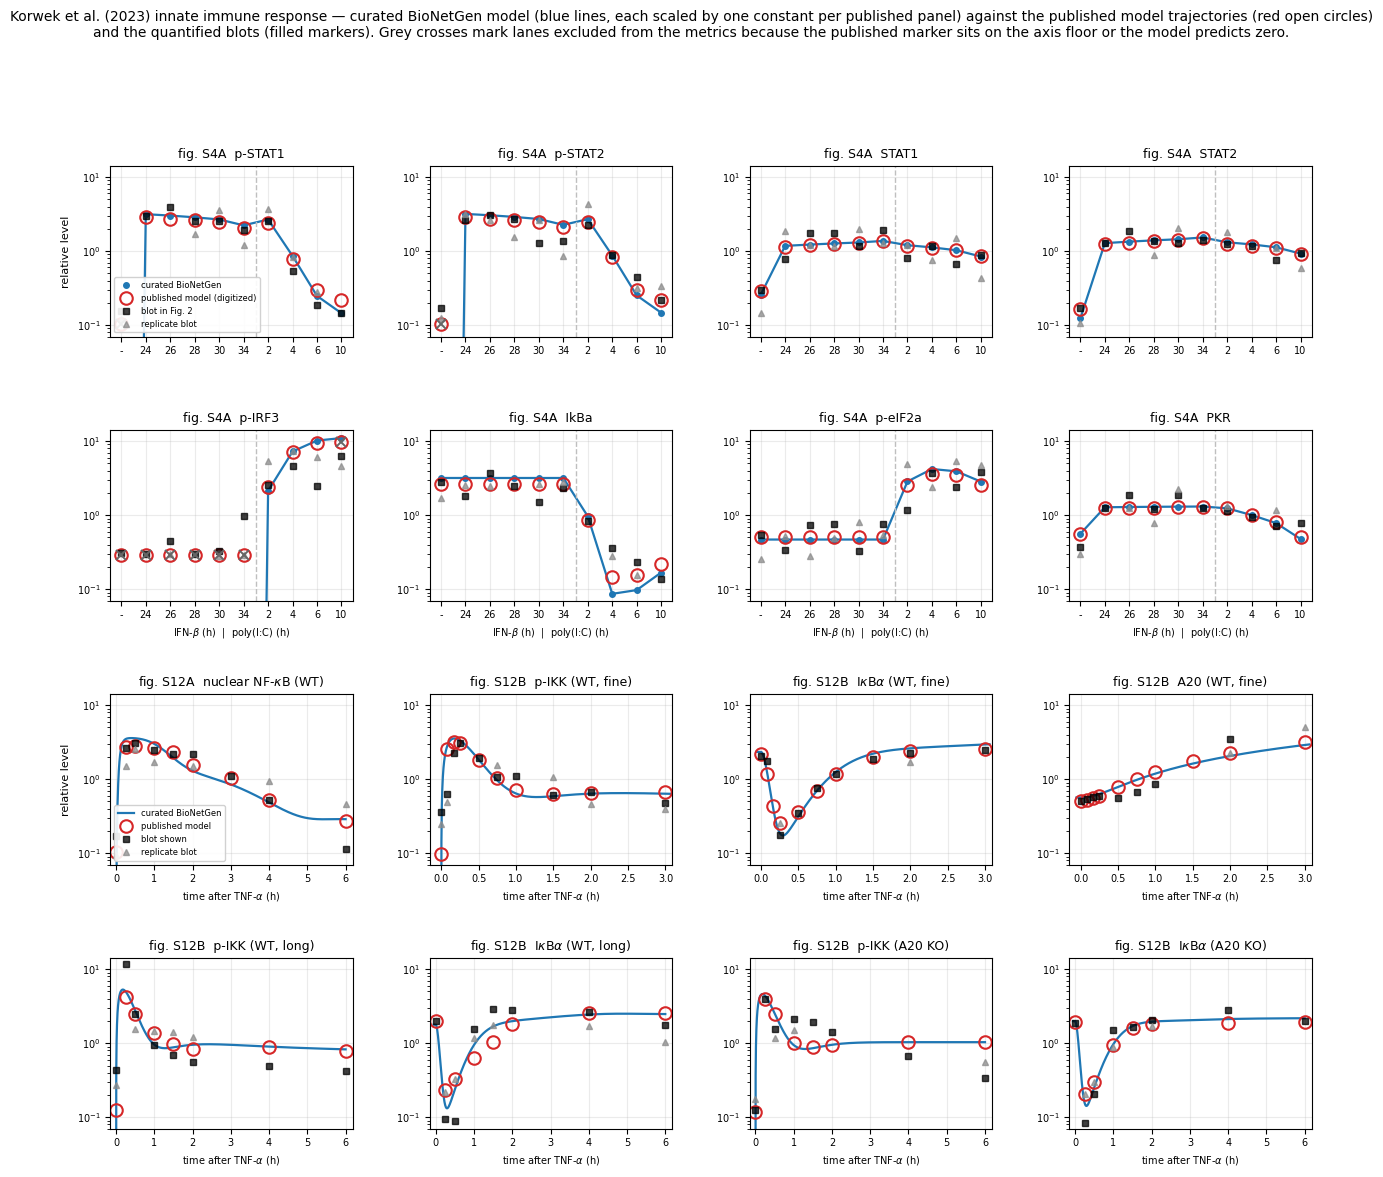

In [9]:
fig = plt.figure(figsize=(15.5, 12.5))
gs = fig.add_gridspec(4, 4, hspace=0.55, wspace=0.32)

# --- row 1-2: fig. S4A, the eight most informative observables -----------------
S4A_SHOW = ["p-STAT1", "p-STAT2", "STAT1", "STAT2",
            "p-IRF3", "IkBa", "p-eIF2a", "PKR"]
for i, observable in enumerate(S4A_SHOW):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    sub, pub, mod, keep, s, _ = compare_panel(s4, "S4A", observable, S4A_LANES)
    x = np.arange(1, 11)
    ax.plot(x, mod * s, "-", color="tab:blue", lw=1.6, zorder=2)
    ax.plot(x, mod * s, "o", color="tab:blue", ms=4, zorder=2,
            label="curated BioNetGen")
    ax.plot(x, pub, "o", mfc="none", mec="tab:red", ms=9, mew=1.5, ls="none",
            zorder=3, label="published model (digitized)")
    ax.plot(x, sub["blot_shown"].to_numpy(float), "s", color="k", ms=4, ls="none",
            alpha=.75, zorder=4, label="blot in Fig. 2")
    ax.plot(x, sub["blot_replicate"].to_numpy(float), "^", color="0.55", ms=4,
            ls="none", alpha=.75, zorder=4, label="replicate blot")
    ax.plot(x[~keep], pub[~keep], "x", color="0.4", ms=7, mew=1.4, ls="none", zorder=5)
    ax.axvline(6.5, color="0.75", ls="--", lw=1)
    ax.set_yscale("log"); ax.set_ylim(0.07, 14); ax.set_xticks(x)
    ax.set_xticklabels(["-", "24", "26", "28", "30", "34", "2", "4", "6", "10"], fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_title(f"fig. S4A  {observable}", fontsize=9)
    ax.grid(alpha=.25)
    if i == 0:
        ax.set_ylabel("relative level", fontsize=8)
        ax.legend(fontsize=6, loc="lower left", framealpha=.9)
    if i >= 4:
        ax.set_xlabel("IFN-$\\beta$ (h)  |  poly(I:C) (h)", fontsize=7)

# --- row 3-4: fig. S12 ---------------------------------------------------------
S12_SHOW = [("S12A", "NF-kB nuclear", "tnfa", "fig. S12A  nuclear NF-$\\kappa$B (WT)"),
            ("S12B_WT_fine", "p-IKK", "tnfa", "fig. S12B  p-IKK (WT, fine)"),
            ("S12B_WT_fine", "IkBa", "tnfa", "fig. S12B  I$\\kappa$B$\\alpha$ (WT, fine)"),
            ("S12B_WT_fine", "A20", "tnfa", "fig. S12B  A20 (WT, fine)"),
            ("S12B_WT_long", "p-IKK", "tnfa", "fig. S12B  p-IKK (WT, long)"),
            ("S12B_WT_long", "IkBa", "tnfa", "fig. S12B  I$\\kappa$B$\\alpha$ (WT, long)"),
            ("S12B_A20KO_long", "p-IKK", "tnfa_ko", "fig. S12B  p-IKK (A20 KO)"),
            ("S12B_A20KO_long", "IkBa", "tnfa_ko", "fig. S12B  I$\\kappa$B$\\alpha$ (A20 KO)")]
for i, (panel, observable, proto, title) in enumerate(S12_SHOW):
    ax = fig.add_subplot(gs[2 + i // 4, i % 4])
    sub, pub, mod, keep, s = cache[(panel, observable)]
    th = sub.time_h.to_numpy(float)
    df = sim[proto]
    m = (df["time"] >= T_STIM - 200) & (df["time"] <= T_STIM + th.max() * 3600 * 1.02)
    ax.plot((df["time"][m] - T_STIM) / 3600, df[S12_MAP[observable]][m] * s, "-",
            color="tab:blue", lw=1.6, label="curated BioNetGen")
    ax.plot(th, pub, "o", mfc="none", mec="tab:red", ms=9, mew=1.5, ls="none",
            label="published model")
    ax.plot(th, sub["blot_shown"].to_numpy(float), "s", color="k", ms=4, ls="none",
            alpha=.75, label="blot shown")
    ax.plot(th, sub["blot_replicate"].to_numpy(float), "^", color="0.55", ms=4,
            ls="none", alpha=.75, label="replicate blot")
    ax.set_yscale("log"); ax.set_ylim(0.07, 14)
    ax.set_xlim(-0.15, th.max() * 1.03)
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7); ax.grid(alpha=.25)
    ax.set_xlabel("time after TNF-$\\alpha$ (h)", fontsize=7)
    if i == 0:
        ax.set_ylabel("relative level", fontsize=8)
        ax.legend(fontsize=6, loc="lower left", framealpha=.9)

fig.suptitle("Korwek et al. (2023) innate immune response — curated BioNetGen model (blue "
             "lines, each scaled by one constant per published panel) against the published "
             "model trajectories (red open circles)\nand the quantified blots (filled "
             "markers). Grey crosses mark lanes excluded from the metrics because the "
             "published marker sits on the axis floor or the model predicts zero.",
             fontsize=10, y=1.005)
fig.savefig("verify_korwek2023.png", dpi=140, bbox_inches="tight")
print("saved verify_korwek2023.png")

## 5. Summary

In [10]:
print("1. SOURCE FIDELITY")
print("   The curated primary file reproduces the authors' data file S2 model exactly")
print("   (max |difference| = 0 over 43 observables x 4321 time points).\n")
print("2. MODEL-SPECIFICATION VERIFICATION")
print(f"   BioNetGen vs an independent SciPy integration of the 53-species system built")
print(f"   from the reaction rules, over {len(spec)} protocol x observable comparisons")
print(f"   and {sum(len(sim[k]) for k in PROTOCOLS)} time points:")
print(f"     active observables    : max normalized deviation "
      f"{active.max_norm_dev.max():.2e}")
print(f"     quiescent observables : max absolute deviation   "
      f"{quiescent.max_abs_dev.max():.2e}\n")
print("3. REPORTED-DATA VERIFICATION")
print(f"   fig. S4  : {s4_stats.n.sum()} published model points in {int(ok.sum())} series,")
print(f"              per-series median relative deviation "
      f"{np.median(s4_stats.median_pct[ok]):.1f}% "
      f"(worst series {s4_stats.median_pct[ok].max():.1f}%)")
print(f"   fig. S12 : {int(s12_stats.n.sum())} published model points in "
      f"{int(ok12.sum())} series,")
print(f"              per-series median relative deviation "
      f"{np.nanmedian(s12_stats.median_pct[ok12]):.1f}% "
      f"(worst series {np.nanmax(s12_stats.median_pct[ok12]):.1f}%)")
print("   after fitting one multiplicative constant per published panel and observable,")
print("   which is the unpublished per-blot normalization the figures carry.")
print("   Digitization alone accounts for roughly 4% of this (about 1 px on a log axis")
print("   with ~50 px per decade); the remainder concentrates on the steepest segments,")
print("   where a 1 px horizontal error moves the value substantially.")

1. SOURCE FIDELITY
   The curated primary file reproduces the authors' data file S2 model exactly
   (max |difference| = 0 over 43 observables x 4321 time points).

2. MODEL-SPECIFICATION VERIFICATION
   BioNetGen vs an independent SciPy integration of the 53-species system built
   from the reaction rules, over 210 protocol x observable comparisons
   and 17885 time points:
     active observables    : max normalized deviation 6.87e-05
     quiescent observables : max absolute deviation   6.37e-08

3. REPORTED-DATA VERIFICATION
   fig. S4  : 179 published model points in 24 series,
              per-series median relative deviation 3.6% (worst series 17.4%)
   fig. S12 : 75 published model points in 9 series,
              per-series median relative deviation 9.7% (worst series 23.1%)
   after fitting one multiplicative constant per published panel and observable,
   which is the unpublished per-blot normalization the figures carry.
   Digitization alone accounts for roughly 4% of thi